Analysind output of minimap mildew reference genome and assemblies to air samples

In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors

Read in the data frames

In [2]:
# List of PAF filenames to process
paf_files = [
    "../Mildew/air_mildew_mapping/mildew_air_mapping_01.paf",
    "../Mildew/air_mildew_mapping/mildew_air_mapping_02.paf",
    "../Mildew/air_mildew_mapping/mildew_air_mapping_03.paf",
    "../Mildew/air_mildew_mapping/mildew_air_mapping_04.paf",
    "../Mildew/air_mildew_mapping/mildew_air_mapping_ref.paf"
]

# Custom labels for each file
labels = [
    "Sample 1",
    "Sample 2",
    "Sample 3",
    "Sample 4",
    "Reference"
]

In [3]:
class alignment_info:
    def __init__(self, q_name, contig, match_bases, map_length, identity, MQ):
        self.q_name = q_name
        self.contig = contig
        self.match_bases = match_bases
        self.map_length = map_length
        self.identity = identity
        self.MQ = MQ

    def print_alignment(self):
        print(f"Query: {self.q_name}, Identity: {self.identity}, MQ: {self.MQ}")

In [4]:
# Dictionary to hold alignments for each file
all_alignments = {}

for label, pafFilename in zip(labels, paf_files):
    alignments = {}
    with open(pafFilename, 'r') as pafFile:
        for line in pafFile:
            fields = line.strip().split('\t')
            q_name = fields[0].strip()
            contig = fields[5].strip()
            match_bases = int(fields[9].strip())
            map_length = int(fields[10].strip())
            identity = (match_bases / map_length) * 100 if map_length > 0 else 0
            MQ = int(fields[11].strip())
            ai = alignment_info(q_name, contig, match_bases, map_length, identity, MQ)
            if q_name not in alignments:
                alignments[q_name] = []
            alignments[q_name].append(ai)
    # Store the alignments for this label
    all_alignments[label] = alignments


Visualise the number of alignments passing filter for each sample

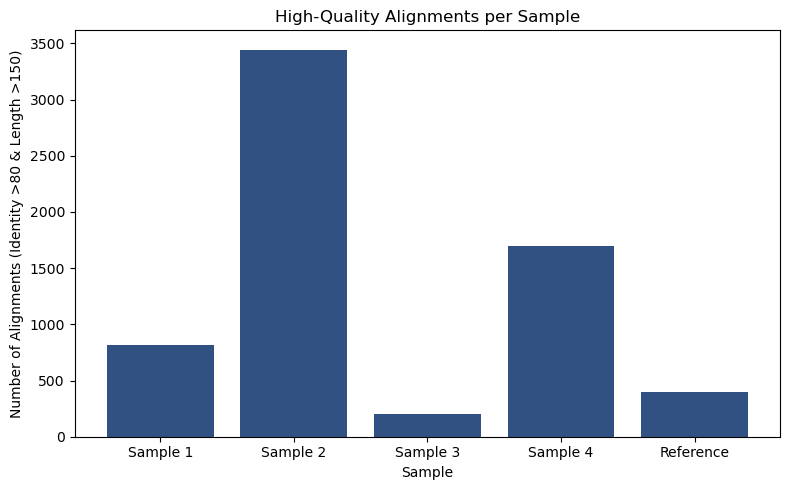

In [5]:
# Count alignments with identity >80 and map_length >150 for each sample
counts = {}
for label, alignments in all_alignments.items():
    count = 0
    for aln_list in alignments.values():
        for aln in aln_list:
            if aln.identity > 80 and aln.map_length > 150:
                count += 1
    counts[label] = count

labels = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(8,5))
plt.bar(labels, values, color='#305182')
plt.xlabel('Sample')
plt.ylabel('Number of Alignments (Identity >80 & Length >150)')
plt.title('High-Quality Alignments per Sample')
plt.tight_layout()
plt.show()

In [6]:
# Create a summary table for each sample
summary = []
for label, alignments in all_alignments.items():
    total = 0
    filtered = 0
    identity_list = []
    length_list = []
    filtered_identity = []
    filtered_length = []
    for aln_list in alignments.values():
        for aln in aln_list:
            total += 1
            identity_list.append(aln.identity)
            length_list.append(aln.map_length)
            if aln.identity > 80 and aln.map_length > 150:
                filtered += 1
                filtered_identity.append(aln.identity)
                filtered_length.append(aln.map_length)
    avg_identity = sum(identity_list) / len(identity_list) if identity_list else 0
    avg_length = sum(length_list) / len(length_list) if length_list else 0
    avg_identity_filtered = sum(filtered_identity) / len(filtered_identity) if filtered_identity else 0
    avg_length_filtered = sum(filtered_length) / len(filtered_length) if filtered_length else 0
    summary.append({
        'Sample': label,
        'Total Alignments': total,
        'Filtered Alignments': filtered,
        'Avg Identity': round(avg_identity, 2),
        'Avg Length': round(avg_length, 2),
        'Avg Identity (Filtered)': round(avg_identity_filtered, 2),
        'Avg Length (Filtered)': round(avg_length_filtered, 2)
    })

summary_df = pd.DataFrame(summary)
summary_df

,Sample,Total Alignments,Filtered Alignments,Avg Identity,Avg Length,Avg Identity (Filtered),Avg Length (Filtered)
0,Sample 1,3103,813,87.98,282.07,90.82,382.14
1,Sample 2,5320,3444,90.23,466.58,93.81,517.54
2,Sample 3,419,206,87.72,398.03,90.21,609.19
3,Sample 4,6510,1696,88.87,219.18,89.70,309.43
4,Reference,2021,397,92.42,196.71,90.27,479.92


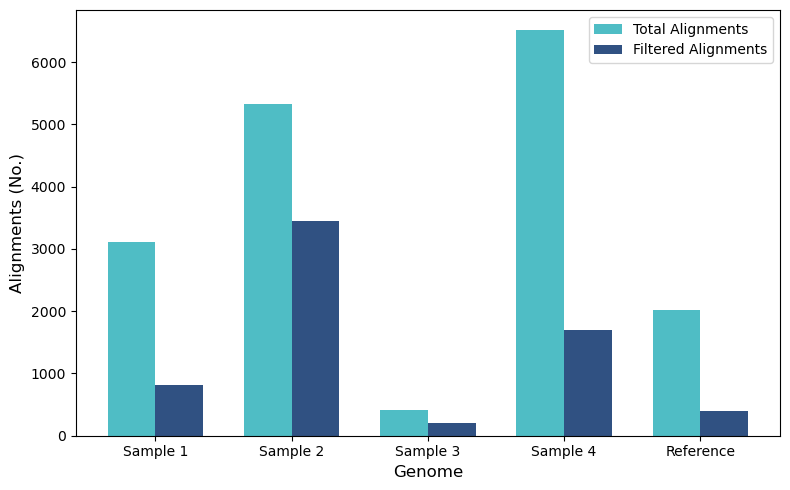

In [11]:
# Grouped bar chart: total vs filtered alignments per sample

samples = list(summary_df['Sample'])
total_counts = list(summary_df['Total Alignments'])
filtered_counts = list(summary_df['Filtered Alignments'])

x = np.arange(len(samples))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width/2, total_counts, width, label='Total Alignments', color='#4FBDC5')
rects2 = ax.bar(x + width/2, filtered_counts, width, label='Filtered Alignments', color='#305182')

ax.set_xlabel('Genome', fontsize=12)
ax.set_ylabel('Alignments (No.)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(samples, rotation=0, fontsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.legend()
plt.tight_layout()


plt.savefig('../Graphs/mildew_mapping_alignments.pdf', dpi=300)

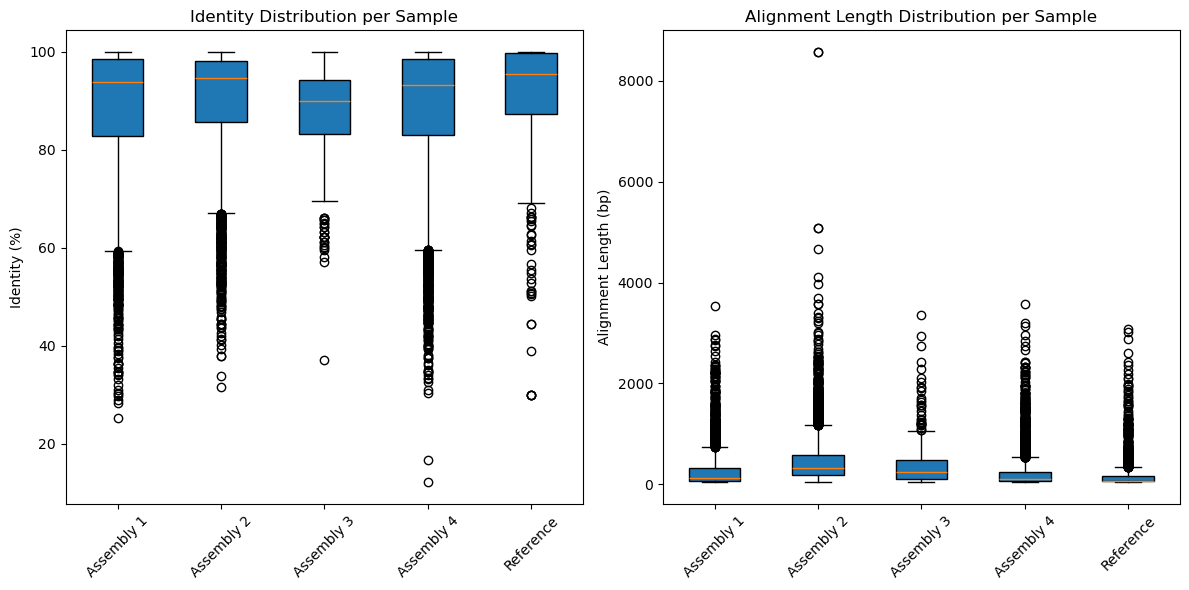

In [25]:
# Prepare data for boxplots
identity_data = []
length_data = []
sample_labels = []
for label, alignments in all_alignments.items():
    identities = []
    lengths = []
    for aln_list in alignments.values():
        for aln in aln_list:
            identities.append(aln.identity)
            lengths.append(aln.map_length)
    identity_data.append(identities)
    length_data.append(lengths)
    sample_labels.append(label)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].boxplot(identity_data, labels=sample_labels, patch_artist=True)
axes[0].set_title('Identity Distribution per Sample')
axes[0].set_ylabel('Identity (%)')
axes[0].set_xticklabels(sample_labels, rotation=45)

axes[1].boxplot(length_data, labels=sample_labels, patch_artist=True)
axes[1].set_title('Alignment Length Distribution per Sample')
axes[1].set_ylabel('Alignment Length (bp)')
axes[1].set_xticklabels(sample_labels, rotation=45)

plt.tight_layout()
plt.show()

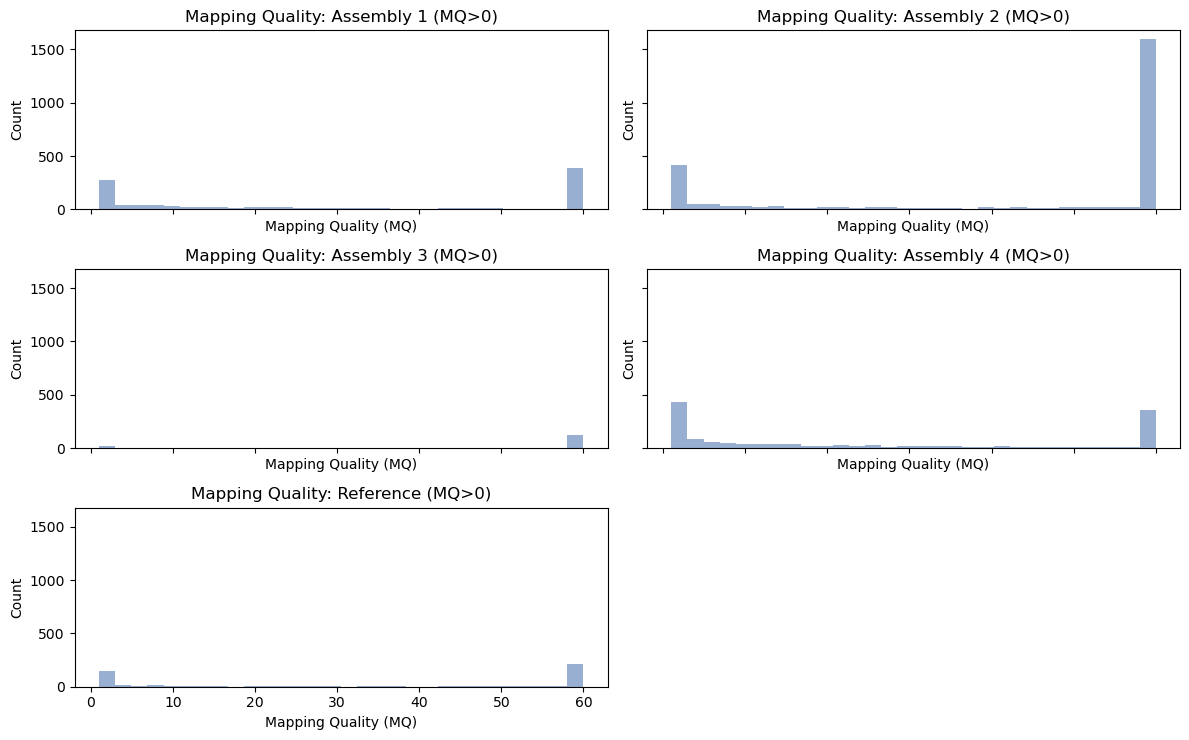

In [34]:
# Histograms of mapping quality (MQ) per sample, excluding MQ=0
import matplotlib.pyplot as plt

mq_data = []
sample_labels = []
for label, alignments in all_alignments.items():
    mqs = []
    for aln_list in alignments.values():
        for aln in aln_list:
            if aln.MQ > 0:  # Exclude MQ=0
                mqs.append(aln.MQ)
    mq_data.append(mqs)
    sample_labels.append(label)

import math
num_samples = len(sample_labels)
num_cols = 2
num_rows = math.ceil(num_samples / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 2.5 * num_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten to easily index

for i, (label, mqs) in enumerate(zip(sample_labels, mq_data)):
    axes[i].hist(mqs, bins=30, color='#6c8ebf', alpha=0.7)
    axes[i].set_title(f'Mapping Quality: {label} (MQ>0)')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel('Mapping Quality (MQ)')

# Hide unused subplots if any
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()